In [ ]:
# using Pkg
# Pkg.activate("../")

using Sivers
import Sivers.Helpers as hp
import Sivers.LightConeCQM as wfs

Solver/spacing options now use Symbols. Use `solver=:vegas` (or `:cuhre`, `:suave`, `:divonne`) and `spacing=:lin` or `:log`. The shared lookup table lives in `Helpers.SOLVERS`.

In [ ]:
# Results for 
#     odderon_distribution(1,-1,[0,0],[.610,0]),
#     odderon_distribution(1,-1,[0,0],[0.5001,0.3501])

# ([0.003967731344722338, 1.4013636728232305e-6], [1.7172974652030593e-5, 3.4930613999975354e-6], [0.5780945122133341, 4.2021941482062175e-12], 10049500, 1, 0)
# ([0.003248746664751642, 0.0022587821074525768], [2.745047314080677e-5, 2.017807732300516e-5], [0.001356867398771733, 0.008476543461395293], 2185000, 0, 0)

# Comparing with old values this seems to check out. So either two body term cancels or still a bug somewhere

In [ ]:
# With ki flipped as well
# ([0.0040032610589848605, -1.4236380382203436e-5], [3.663788639751748e-5, 1.4338130621924913e-5], [1.9189721873758003e-6, 9.331063535511497e-6], 10049500, 1, 0)
# ([0.003229643499319246, 0.002254683884863326], [2.410227792229085e-5, 2.017985291318496e-5], [5.88862292261183e-13, 1.2864598275541539e-11], 9652500, 0, 0)

Normalization

In [2]:
normalize_wavefunction()

(21693.23305361701, [2.124612298660601e-13, 1.1649245378190398e-23], [0.0, 0.0], 5433735, 0, 5998)

Form factors

In [3]:
# [re,im], [err_re,err_im], [prob_re,prob_im], nevals, fail, nregions
f1_form_factor([0.1,0])

([0.972194217812095, 6.3087407380926e-18], [9.719693965044207e-5, 1.2737108333585669e-12], [0.0, 0.0], 5333169, 0, 5887)

# Sivers Function

test vanishing of cubic color corellator

In [18]:
function test(s01,s02,x)
    k = [0,0]
    (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
    # Momenta
    r1, ϕ1, d2k1 = hp.cuba_to_polar(x[3:4])    # k1
    r2, ϕ2, d2k2 = hp.cuba_to_polar(x[5:6])    # k2
    r3, ϕ3, d2q2 = hp.cuba_to_polar(x[7:8])    # q2
    
    # Reconstruct cartesian momenta from polar coordinates
    k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
    k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
    k3 = - (k1 + k2)  # Enforce transverse momentum conservation
    d4k = d2k1 * d2k2

    q2 = [r3 * cos(ϕ3), r3 * sin(ϕ3)]
    # q2 = [0,0]
    # Jacobian
    d8x = d2x * d4k * d2q2 # 2 + 4 + 2 = 8d integral

    # Flip momenta to project out Sivers function
    q1, q2, q3 = k, q2, - (k + q2)
    # k1, k2, k3 = s * k1, s * k2, s * k3  
    ccc = cubic_color_correlator(s01,s02,q1,q2,q3,x1,x2,x3,k1,k2,k3) * d8x
    return ccc
end

# Use this to check cubic color correlator vanishes when one of the q_i -> 0

for i in 1:100000
    x = rand(8)
    tmp = test(1,-1,x)
    if abs(real(tmp)) > 1e-12 || abs(imag(tmp)) > 1e-12
        println(tmp)
    end
end

for i in 1:100000
    x = rand(8)
    tmp = test(1,1,x)
    if abs(real(tmp)) > 1e-12 || abs(imag(tmp)) > 1e-12
        println(tmp)
    end
end

2.048958865750004e-12 + 0.0im
-4.5959269784360484e-11 + 0.0im
-4.513302008921915e-12 + 0.0im
5.220394094154287e-12 + 0.0im
1.1184239856532075e-12 + 0.0im
3.5642295191042392e-9 + 0.0im
4.71911877178488e-12 + 0.0im
2.1650337038437938e-11 + 0.0im
4.4944742464486884e-11 + 0.0im
7.308277311263334e-11 + 0.0im
2.7690098284170954e-11 + 0.0im
3.5117350184336534e-12 + 0.0im
1.4195531248241368e-12 + 0.0im
3.729882854262119e-12 + 0.0im
9.057135557648943e-11 + 0.0im
1.752981530421626e-12 + 0.0im
3.573461603284076e-12 + 0.0im
8.101317100812707e-12 + 0.0im
3.120494459138902e-12 + 0.0im
-2.548687453359319e-12 + 0.0im
-2.1765145090550833e-12 + 0.0im
5.951416230906235e-12 + 0.0im
2.624864492326777e-12 + 0.0im
1.5713546441815257e-9 + 0.0im
1.4078697485499138e-12 + 0.0im
-1.2707670087953867e-7 + 0.0im
1.660526335288535e-12 + 0.0im
6.5082494062616526e-9 + 0.0im
1.7472693113312132e-8 + 0.0im
1.1371436121962563e-10 + 0.0im
-1.1814043338148655e-7 + 0.0im
-9.666080625669407e-10 + 0.0im
2.7935288175957826e-12 +

In [19]:
function test(s01,s02,x)
    k = [0.1,0]
    (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
    # Momenta
    r1, ϕ1, d2k1 = hp.cuba_to_polar(x[3:4])    # k1
    r2, ϕ2, d2k2 = hp.cuba_to_polar(x[5:6])    # k2
    r3, ϕ3, d2q2 = hp.cuba_to_polar(x[7:8])    # q2
    
    # Reconstruct cartesian momenta from polar coordinates
    k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
    k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
    k3 = - (k1 + k2)  # Enforce transverse momentum conservation
    d4k = d2k1 * d2k2

    q2 = [r3 * cos(ϕ3), r3 * sin(ϕ3)]
    # Jacobian
    d8x = d2x * d4k * d2q2 # 2 + 4 + 2 = 8d integral

    total = complex(0,0)
    for s in (+1,-1)
        # Flip momenta to project out Sivers function
        q1, q2, q3 = s * k, s * q2, - s * (k + q2)
        ccc = cubic_color_correlator(s01, s02, q1, q2, q3, x1, x2, x3, s*k1, s*k2, s*k3)
        total += s * ccc
    end
    return total * d8x
end

# Use this to check that the integrand vanishes when s01=s02

for i in 1:10000
    x = rand(8)
    tmp = test(1,1,x)
    if abs(real(tmp)) > 1e-12 || abs(imag(tmp)) > 1e-12
        println(tmp)
    end
end

In [ ]:
# We choose k_T = [k,0], vanishing regulator and the vegas algorithm
k, mu, solver = 0.1, 0.0, :vegas
# [re,im], [err_re,err_im], [prob_re,prob_im], nevals, fail, nregions
# Note that fail is 1 because we did not meet the specified relative precision goal of 
# < 9e-3 within 10^7 evaluations but we are still within reasonable error bars and the
# result is stable under repeated calls.
gluon_sivers(k; μ=mu, solver=solver)

([-0.05340046374037633, -0.00010585498915846471], [0.0005206177166279495, 0.00018544090866359571], [0.06862073096634858, 5.644373857194296e-13], 10049500, 1, 0)

# Plots now done separately in Python

In [ ]:
############################################################################
############################################################################
###   ___  _     _       _          __  __   _          _                ###
###  / _ \| | __| |  ___| |_ _   _ / _|/ _| | |__   ___| | _____      __ ###
### | | | | |/ _` | / __| __| | | | |_| |_  | '_ \ / _ \ |/ _ \ \ /\ / / ###
### | |_| | | (_| | \__ \ |_| |_| |  _|  _| | |_) |  __/ | (_) \ V  V /  ###
###  \___/|_|\__,_| |___/\__|\__,_|_| |_|   |_.__/ \___|_|\___/ \_/\_/   ###
###                                                                      ###
############################################################################
############################################################################

Proton radius

Linearized result:
  Proton radius R[fm] = 0.8005867626896324
Dipole fit result:
  M_D = 0.5548066716519863
  Proton radius R[fm] = 0.8719690099601666
  Uncertainty: M_D^2 ± 0.00951692175863781, R ± 0.06825227055702685


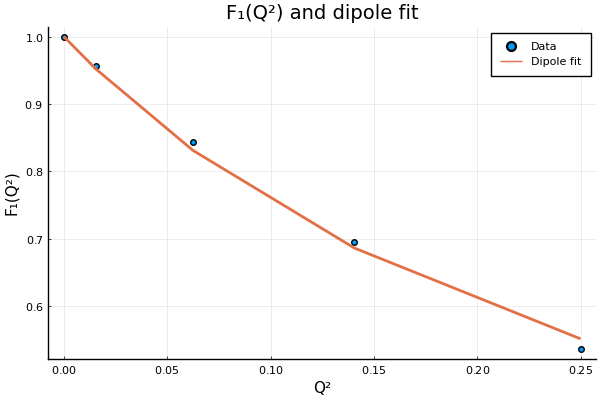

In [9]:
using LsqFit, Plots
Q2_array = Δ_array.^2
F1 = real(results)

# Linearized derivative
println("Linearized result:")
dF_qQ2 = (F1[2] - F1[1]) / (Q2_array[2] - Q2_array[1])
R = sqrt(-6 * dF_qQ2) 

hbarc = 0.1975
println("  Proton radius R[fm] = ", R * hbarc)

# Restrict to Q^2 ≤ Qmax2
Qmax2 = 0.28
mask = Q2_array .<= Qmax2
x = Q2_array[mask]
y = F1[mask]

# Dipole model: p[1] = M_D^2
# model(x,p) = 1.0 ./ (1 .+ x ./ p[1])
# More elegant way to write
@. model(x,p) = 1.0 / (1 + x / p[1])

# Initial guess for M_D^2 (~0.71 GeV^2 for proton)
p0 = [0.7]

fit = curve_fit(model, x, y, p0)

MD2 = fit.param[1]
R = sqrt(6 / MD2) 

println("Dipole fit result:")
println("  M_D = ", sqrt(MD2))
println("  Proton radius R[fm] = ", R * hbarc)

# Error estimate
cov = estimate_covar(fit)
σ_MD2 = sqrt(cov[1,1])
σ_R = 0.5 * sqrt(6) * σ_MD2 / (MD2^(3/2))
println("  Uncertainty: M_D^2 ± ", σ_MD2, ", R ± ", σ_R)

F1_fit = model(x, fit.param)

plot(x, y, seriestype=:scatter, label="Data", xlabel="Q²", ylabel="F₁(Q²)",
     title="F₁(Q²) and dipole fit", legend=:topright)
plot!(x, F1_fit, label="Dipole fit", lw=2)


# Benchmark tests

Things I have tried to speed up:
- Summation outside integrand and summing contributions obtained by cuhre slightly faster
- Summation inside integrand is slightly slower
- Parallelizing with CUBACORES actually takes longer
- No speed up with parallelization in general

In [ ]:
using Cuba
using BenchmarkTools
"""
    cuba_to_polar(x)

Transform a Cuba sample `x ∈ [0,1]^2` into polar coordinates.

# Arguments
- `x::Vector{<:Real}`: Sample point in the unit circle `[0,1]^2`.

# Returns
- `r::Real`: Radius
- `ϕ::Real`: Azimuthal angle
- `jac::Real`: Jacobian determinant of the transformation

# Notes
Throws an `ArgumentError` if called with `length(x) != 2`.
"""
function cuba_to_polar(x::Vector{<:Real})
    n = length(x)            
    if n != 2
        throw(ArgumentError("Input must be two-dimensional for polar coordinates"))
    end
    # r ∈ [0, ∞)
    r = x[1] / (1 - x[1])
    drdx = 1 / (1 - x[1])^2
    ϕ = 2π * x[2]
    jac = 2π * r * drdx

    return r, ϕ, jac
end

function cuba_to_hyperspherical(x::Vector{<:Real})
    n = length(x)            
    if n < 2
        throw(ArgumentError("Need at least 2 dimensions for hyperspherical coordinates"))
    end

    # r ∈ [0, ∞)
    r = x[1] / (1 - x[1])
    drdx = 1 / (1 - x[1])^2

    thetas = zeros(eltype(x), n-1)

    jac = r^(n-1) * drdx

    # first n-2 angles in [0, π]
    for i in 1:(n-2)
        cosθ = 2*x[i+1] - 1
        θ = acos(cosθ)
        thetas[i] = θ
        jac *= 2 * sin(θ)^(n-i-2)
    end

    # last angle in [0,2π)
    ϕ = 2π * x[n]
    thetas[end] = ϕ
    jac *= 2π

    return r, thetas, jac
end

function integrand(x,f)
    r1, ϕ1, d2k1 = cuba_to_polar(x)
    f[1] = exp(-r1^2) * d2k1
end
@btime integral, err = cuhre(integrand,2,1)
println(integral[1])

function integrand(x,f)
    r1, (ϕ1,), d2k1 = cuba_to_hyperspherical(x)
    f[1] = exp(-r1^2) * d2k1
end

@btime integral, err = cuhre(integrand,2,1)
println(integral[1])


  46.419 μs (2343 allocations: 73.31 KiB)
3.141592697100627
  59.469 μs (2928 allocations: 109.88 KiB)
3.141592697100627
